In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [196]:
df = pd.read_csv('CreditScoring.csv')
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [197]:
df.columns = df.columns.str.lower()

In [198]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [199]:
df.status.unique()

array([1, 2, 0])

In [200]:
df.status = df.status.map({1: 'ok', 2:'default', 0: 'unknown'})

In [201]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,default,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,ok,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,ok,0,1,36,26,1,1,1,46,107,0,0,310,910


In [202]:
df.home.unique()

array([1, 2, 5, 3, 6, 4, 0])

In [203]:
df.home = df.home.map({1 : 'rent', 2:'owner', 3 : 'private', 4 :' ignore', 5 : 'parents', 6: 'other', 0: 'unknown'})

In [204]:
df.home.value_counts()

home
owner      2107
rent        973
parents     783
other       319
private     247
 ignore      20
unknown       6
Name: count, dtype: int64

In [205]:
marital_values = {
    1 :'single',
    2 : 'married',
    3 : 'widow',
    4 : 'separated',
    5 : 'divorced',
    0 : 'unknown'
    }

In [206]:
df.marital = df.marital.map(marital_values)
df.marital.value_counts()

marital
married      3241
single        978
separated     130
widow          67
divorced       38
unknown         1
Name: count, dtype: int64

In [207]:
df.marital.head()

0    married
1      widow
2    married
3     single
4     single
Name: marital, dtype: object

In [208]:
record_values = {
    1 : 'no',
    2 : 'yes',
    3 : 'unknown'
}

In [209]:
df.status.value_counts()

status
ok         3200
default    1254
unknown       1
Name: count, dtype: int64

In [210]:
df.records = df.records.map(record_values)

In [211]:
df.records.head()

0     no
1     no
2    yes
3     no
4     no
Name: records, dtype: object

In [212]:
job_values = {
    1 : 'fixed',
    2 : 'parttime',
    3 : 'freelance',
    4 : 'others',
    0 : 'unknown'}

In [213]:
df.job = df.job.map(job_values)

In [214]:
df.job.head()

0    freelance
1        fixed
2    freelance
3        fixed
4        fixed
Name: job, dtype: object

In [215]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [297]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4454.0,4454.0,4454.0,4454.0,4420.0,4407.0,4436.0,4454.0,4454.0
mean,8.0,46.0,37.0,56.0,131.0,5404.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11574.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1117.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [217]:
df.income.max()

np.int64(99999999)

In [218]:
df.income.replace(to_replace=99999999, value = np.nan)

0       129.0
1       131.0
2       200.0
3       182.0
4       107.0
        ...  
4450     92.0
4451     75.0
4452     90.0
4453    140.0
4454    140.0
Name: income, Length: 4455, dtype: float64

In [219]:
for c in ['income', 'assets', 'debt']:
          df[c] = df[c].replace(to_replace=99999999, value = np.nan)

In [220]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [221]:
df = df[df.status != 'unknown'].reset_index(drop=True)

In [222]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,parttime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [223]:
# Train /test/validation split
from sklearn.model_selection import train_test_split
df_full_train , df_test = train_test_split(df, test_size = 0.2, random_state = 11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state =11)

In [224]:
df_train = df_train.reset_index(drop =True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [225]:
len(df_train), len(df_val), len(df_test)

(2672, 891, 891)

In [226]:
## target variable
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [227]:
del df_train['status']
del df_val['status']
del df_test['status']

In [228]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,parttime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,18,private,36,45,married,no,fixed,45,220.0,20000.0,0.0,800,1600
2668,7,private,60,29,married,no,fixed,60,51.0,3500.0,500.0,1000,1290
2669,1,parents,24,19,single,no,fixed,35,28.0,0.0,0.0,400,600
2670,15,owner,48,43,married,no,freelance,60,100.0,18000.0,0.0,2500,2976


In [229]:
df_val

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,6,rent,36,31,separated,no,fixed,49,140.0,0.0,0.0,550,999
1,18,rent,60,38,married,no,fixed,56,108.0,0.0,0.0,1000,1307
2,17,rent,24,40,married,yes,fixed,58,128.0,0.0,0.0,700,982
3,2,other,48,29,married,no,fixed,75,96.0,6000.0,3000.0,1200,1521
4,25,rent,42,61,married,no,fixed,57,121.0,0.0,0.0,750,830
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,owner,12,21,single,no,fixed,35,147.0,1500.0,0.0,350,350
887,12,owner,60,45,married,no,fixed,75,131.0,5000.0,0.0,1150,1452
888,2,owner,60,36,married,yes,freelance,60,140.0,29000.0,0.0,3900,4812
889,3,parents,24,25,single,yes,fixed,35,128.0,0.0,0.0,300,1397


### Decision Trees
* How a decision tree looks like
* Training a deesion tree
* overfitting
* Controlling the size of a tree

In [230]:
### Manual conditional logic Tree model
def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'parttime':
            return 'default'
        else: 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

In [231]:
xi = df_train.iloc[0].to_dict()

In [232]:
assess_risk(xi)

'ok'

In [233]:
x2 = df_train.iloc[11].to_dict()
x2

{'seniority': 15,
 'home': 'rent',
 'time': 48,
 'age': 40,
 'marital': 'married',
 'records': 'no',
 'job': 'fixed',
 'expenses': 57,
 'income': 120.0,
 'assets': 0.0,
 'debt': 0.0,
 'amount': 1000,
 'price': 1500}

In [234]:
assess_risk(x2)

'default'

In [235]:
x3 = df_val.iloc[0].to_dict()

In [236]:
assess_risk(x3)

'default'

In [237]:
x4 = df_test.iloc[0].to_dict()

In [238]:
assess_risk(x4)

'ok'

In [289]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
import seaborn as sns

In [240]:
train_dicts = df_train.fillna(0).to_dict(orient = 'records')

In [241]:
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(train_dicts)

In [242]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [243]:
val_dicts = df_val.fillna(0).to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

In [244]:
y_pred = dt.predict_proba(X_val)[:,1]

In [245]:
roc_auc_score(y_val, y_pred)

0.6594384974934006

In [246]:
y_pred = dt.predict_proba(X_train)[:,1]

In [247]:
roc_auc_score(y_train, y_pred)

1.0

In [272]:
dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [273]:
y_pred = dt.predict_proba(X_train)[:,1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

train: 0.8164293560926146


In [274]:
y_pred = dt.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)

val: 0.7612827250490422


In [275]:
from sklearn.tree import export_text

In [276]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- seniority <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- seniority >  0.50
|   |   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- assets <= 8250.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  8250.00
|   |   |   |   |--- class: 0
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- assets <= 4500.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  4500.00
|   |   |   |   |--- class: 0
|   |   |--- income >  103.50
|   |   |   |--- expenses <= 89.00
|   |   |   |   |--- class: 0
|   |   |   |--- expenses >  89.00
|   |   |   |   |--- class: 1
|--- records=no >  0.50
|   |--- job=parttime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- assets <= 4250.00
|   |   |   |   |--- class: 0
|   |   |   |--- assets >  4250.00
|   |   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- seniority <= 5.50
|   |

### Decision Trees parameter Tuning
* selecting max_depth
* selecting min_samples_leaf

In [277]:
for d in [1, 2, 3,4, 5,6 ,10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)
    
    y_pred_train = dt.predict_proba(X_train)[:,1]
    auc_train = roc_auc_score(y_train, y_pred_train)
    
    y_pred_val = dt.predict_proba(X_val)[:,1]
    auc_val = roc_auc_score(y_val, y_pred_val)
    
    print(f'max_depth={d} --> train: {auc_train:.3f} | val: {auc_val:.3f}')

max_depth=1 --> train: 0.628 | val: 0.606
max_depth=2 --> train: 0.705 | val: 0.669
max_depth=3 --> train: 0.776 | val: 0.739
max_depth=4 --> train: 0.816 | val: 0.761
max_depth=5 --> train: 0.843 | val: 0.767
max_depth=6 --> train: 0.875 | val: 0.760
max_depth=10 --> train: 0.964 | val: 0.691
max_depth=15 --> train: 0.998 | val: 0.651
max_depth=20 --> train: 1.000 | val: 0.649
max_depth=None --> train: 1.000 | val: 0.663


In [280]:
scores = []
for d in [4, 5, 6]:
    for s in [1, 2,5, 10, 15, 20, 100,200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
        
        y_pred_train = dt.predict_proba(X_train)[:,1]
        auc_train = roc_auc_score(y_train, y_pred_train)
        
        y_pred_val = dt.predict_proba(X_val)[:,1]
        auc_val = roc_auc_score(y_val, y_pred_val)
        
        print(f'max_depth={d} | min_samples_leaf={s} --> train: {auc_train:.3f} | val: {auc_val:.3f}')
        scores.append((d, s, auc_train, auc_val))

max_depth=4 | min_samples_leaf=1 --> train: 0.816 | val: 0.761
max_depth=4 | min_samples_leaf=2 --> train: 0.816 | val: 0.761
max_depth=4 | min_samples_leaf=5 --> train: 0.816 | val: 0.761
max_depth=4 | min_samples_leaf=10 --> train: 0.816 | val: 0.761
max_depth=4 | min_samples_leaf=15 --> train: 0.817 | val: 0.764
max_depth=4 | min_samples_leaf=20 --> train: 0.817 | val: 0.761
max_depth=4 | min_samples_leaf=100 --> train: 0.803 | val: 0.756
max_depth=4 | min_samples_leaf=200 --> train: 0.794 | val: 0.747
max_depth=4 | min_samples_leaf=500 --> train: 0.713 | val: 0.680
max_depth=5 | min_samples_leaf=1 --> train: 0.843 | val: 0.767
max_depth=5 | min_samples_leaf=2 --> train: 0.843 | val: 0.767
max_depth=5 | min_samples_leaf=5 --> train: 0.843 | val: 0.768
max_depth=5 | min_samples_leaf=10 --> train: 0.843 | val: 0.762
max_depth=5 | min_samples_leaf=15 --> train: 0.840 | val: 0.773
max_depth=5 | min_samples_leaf=20 --> train: 0.837 | val: 0.774
max_depth=5 | min_samples_leaf=100 --> trai

In [284]:
df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc_train', 'auc_val'])
df_scores.sort_values(by='auc_val', ascending=False).head()

,max_depth,min_samples_leaf,auc_train,auc_val
22,6,15,0.861244,0.785474
21,6,10,0.865779,0.778299
24,6,100,0.826507,0.776434
23,6,20,0.858795,0.773634
14,5,20,0.837485,0.773537


In [285]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns='max_depth', values='auc_val')

In [287]:
df_scores_pivot.round(3)

max_depth,4,5,6
min_samples_leaf,,,
1,0.761,0.767,0.762
2,0.761,0.767,0.756
5,0.761,0.768,0.760
10,0.761,0.762,0.778
15,0.764,0.773,0.785
20,0.761,0.774,0.774
100,0.756,0.763,0.776
200,0.747,0.759,0.768
500,0.680,0.680,0.680


<Axes: xlabel='max_depth', ylabel='min_samples_leaf'>

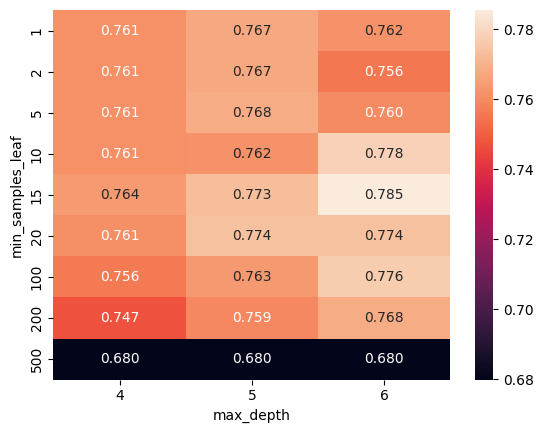

In [295]:
sns.heatmap(df_scores_pivot, annot=True, fmt ='.3f')

In [296]:
# Final Deciasion Tree model
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Ensembles and Random Forest
* Board of experts
* Ensembling models
* Random Forest- ensembling decision trees
* Tuning random forest